In [2]:
import pandas as pd
import umap
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines
import numpy as np
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, squareform
from scipy.stats import gaussian_kde, chi2_contingency
from matplotlib.patches import Rectangle
from skbio.stats.distance import DistanceMatrix, permanova, permdisp
from skbio.stats.ordination import pcoa
from skbio.diversity import beta_diversity
import matplotlib.colors as mcolors
import seaborn as sns

/Users/benoitdepins/miniconda3/envs/subcarb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sample_table = pd.read_csv("../data_processed/sample_table.csv", index_col=0)
otu_rpo = pd.read_csv("../data_processed/otu_rpo.csv", index_col=0)
tax = pd.read_csv("../data_processed/tax.csv", index_col=0)

color_sample_group = {
    'subsurface_sample': "#ad8b56ff",
    'soil': "#85ba89ff",
    'marine_water': "#57a8d1ff",
    'freshwater': "#c2e8e5ff"
}

color_source = {
    'coevolve': "#fc8d62",
    'public_archives': "#e78ac3",
    'tara': "#66c2a5",
    'malaspina': "#8da0cb",
    'neon': "#a6d854",
}

# Functional diversity across sample groups

In [4]:
embedding_bc = umap.UMAP(
    n_neighbors=50,
    min_dist=0.9,
    metric='braycurtis',
    random_state=2,
    n_jobs=1
).fit_transform(otu_rpo.T)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [5]:
label_dict = {
    'subsurface_sample': 'subsurface',
    'soil':              'soil',
    'marine_water':      'marine water',
    'freshwater':        'freshwater',
}

sample_groups = sample_table.loc[otu_rpo.T.index, "sample_group"].astype(str)

DRAW_ORDER   = ['subsurface_sample', 'soil', 'freshwater', 'marine_water']
LEGEND_ORDER = ['marine_water', 'freshwater', 'soil', 'subsurface_sample']

In [6]:
def _umap_plot(ax, embedding, groups, color_dict, draw_order, legend_order,
               label_map=None, legend_loc='best'):
    fig = ax.get_figure()
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    for group in draw_order:
        mask = (groups == group).values
        pts  = embedding[mask]
        lbl  = label_map[group] if label_map else group
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=color_dict[group], marker='o', s=50,
                   edgecolors='black', linewidths=0.3,
                   alpha=0.80, zorder=3, label=lbl, rasterized=True)

    ax.set_xlabel("UMAP 1", fontsize=12, labelpad=6)
    ax.set_ylabel("UMAP 2", fontsize=12, labelpad=6)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
        spine.set_color('#555555')

    handles = [
        plt.Line2D([0], [0], marker='o', color='none',
                   markerfacecolor=color_dict[g],
                   markeredgecolor='white', markeredgewidth=0.4,
                   markersize=8,
                   label=label_map[g] if label_map else g)
        for g in legend_order
    ]
    legend = ax.legend(handles=handles, fontsize=9, frameon=True,
                       framealpha=0.92, edgecolor='#cccccc', loc=legend_loc)
    legend.get_frame().set_linewidth(0.6)
    return fig, ax

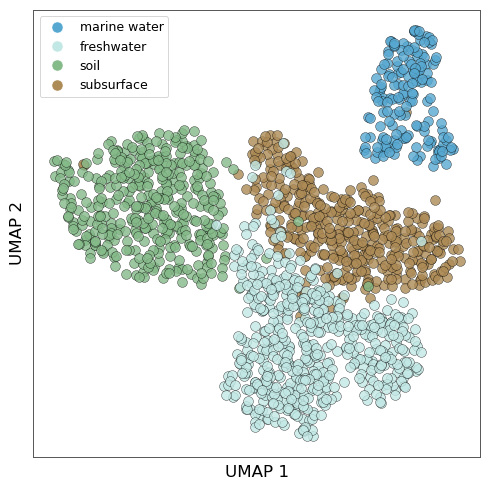

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
_umap_plot(ax, embedding_bc, sample_groups,
           color_sample_group, DRAW_ORDER, LEGEND_ORDER,
           label_map=label_dict)
plt.tight_layout()
plt.savefig("../outputs/umap_sample_group_pub.svg", format="svg",
            bbox_inches='tight', dpi=300, transparent=True)
plt.show()

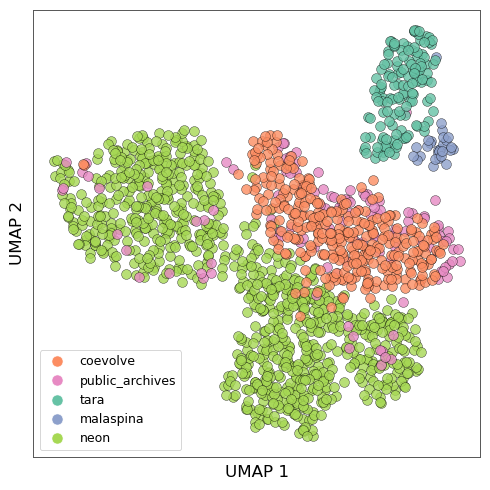

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
_umap_plot(ax, embedding_bc,
           sample_table.loc[otu_rpo.T.index, "source"].astype(str),
           color_source,
           ['neon', 'public_archives', 'malaspina', 'tara', 'coevolve'],
           ['coevolve', 'public_archives', 'tara', 'malaspina', 'neon'],
           legend_loc='lower left')
plt.tight_layout()
plt.savefig("../outputs/umap_source_pub.png", format="png",
            bbox_inches='tight', dpi=500, transparent=True)
plt.show()

In [9]:
X        = otu_rpo.T.copy()
grouping = sample_table.loc[X.index, "sample_group"].astype(str)
grouping.index = grouping.index.astype(str)

dm = DistanceMatrix(squareform(pdist(X.values, metric="braycurtis")),
                    ids=grouping.index.tolist())

permanova_res = permanova(dm, grouping, permutations=999)
permdisp_res  = permdisp(dm, grouping, permutations=999)

perm_F = permanova_res["test statistic"]
n, k = len(dm.ids), grouping.nunique()
perm_R2 = (perm_F * (k - 1)) / (perm_F * (k - 1) + (n - k))

print("PERMANOVA:")
print(permanova_res)
print(f"R² = {perm_R2:.3f}")
print("\nPERMDISP:")
print(permdisp_res)


/Users/benoitdepins/miniconda3/envs/subcarb/lib/python3.12/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:157: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(


PERMANOVA:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1513
number of groups                  4
test statistic            178.11925
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object
R² = 0.262

PERMDISP:
method name                PERMDISP
test statistic name         F-value
sample size                    1513
number of groups                  4
test statistic            76.631055
p-value                       0.001
number of permutations          999
Name: PERMDISP results, dtype: object


/Users/benoitdepins/miniconda3/envs/subcarb/lib/python3.12/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:157: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(


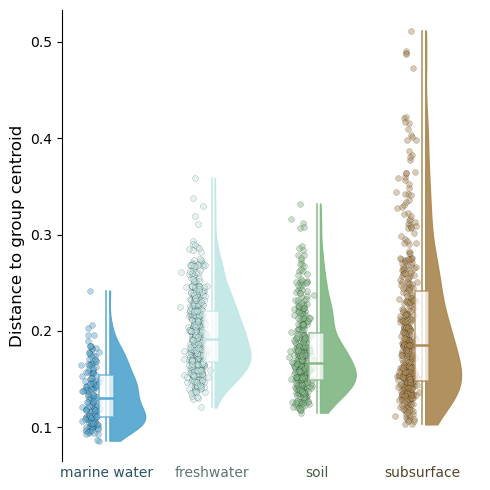

In [10]:
pcoa_res  = pcoa(dm)
coords    = pcoa_res.samples.loc[:, pcoa_res.eigvals > 0]
centroids = coords.groupby(grouping).mean()

dist_df = grouping.to_frame("sample_group")
dist_df["distance_to_centroid"] = [
    np.linalg.norm(coords.loc[sid].values - centroids.loc[g].values)
    for sid, g in grouping.items()
]

plot_order = ['marine_water', 'freshwater', 'soil', 'subsurface_sample']

fig, ax = plt.subplots(figsize=(5.0, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

rng = np.random.default_rng(0)

for i, g in enumerate(plot_order):
    y = dist_df.loc[dist_df["sample_group"] == g, "distance_to_centroid"].values
    y = y[~np.isnan(y)]

    if len(y) == 0:
        continue

    color = color_sample_group[g]

    ax.scatter(rng.normal(loc=i - 0.14, scale=0.04, size=len(y)), y,
               s=18, c=color, edgecolors="black",
               linewidths=0.2, alpha=0.45, zorder=3, rasterized=True)

    y_grid = np.linspace(y.min(), y.max(), 300)
    if len(np.unique(y)) > 1:
        dens = gaussian_kde(y)(y_grid)
        dens = dens / dens.max()
        ax.fill_betweenx(y_grid, i + 0.03, i + 0.03 + 0.34 * dens,
                         facecolor=color, edgecolor=color,
                         linewidth=1.0, alpha=0.95, zorder=2)

    q1, med, q3 = np.percentile(y, [25, 50, 75])
    ax.plot([i, i], [y.min(), y.max()], color=color, linewidth=1.2, alpha=0.9, zorder=4)
    ax.add_patch(Rectangle((i - 0.07, q1), 0.14, q3 - q1,
                            facecolor="white", edgecolor=color,
                            linewidth=1.2, alpha=0.75, zorder=5))
    ax.plot([i - 0.07, i + 0.07], [med, med], color=color, linewidth=1.8, zorder=6)

ax.set_xticks(np.arange(len(plot_order)))
ax.set_xticklabels([label_dict[g] for g in plot_order])

for tick, group in zip(ax.get_xticklabels(), plot_order):
    r, g_col, b = mcolors.to_rgb(color_sample_group[group])
    tick.set_color((r * 0.5, g_col * 0.5, b * 0.5))

ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="x", length=0)
ax.set_ylabel("Distance to group centroid", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

perm_F = permanova_res["test statistic"]
perm_p = permanova_res["p-value"]
n, k   = len(dm.ids), grouping.nunique()


plt.tight_layout()
plt.savefig("../outputs/distance_to_centroid_xlabels_colored.svg", format="svg", bbox_inches='tight', dpi=300, transparent=True)
plt.show()

# Zoom into carbon fixation

In [11]:
def build_func_df(tax_col, categories, otu_df, sample_order):
    rows = {}
    for cat in categories:
        idx = tax.index[tax[tax_col].str.contains(cat, na=False)].intersection(otu_df.index)
        rows[cat] = otu_df.loc[idx, sample_order].sum(axis=0)
    df = pd.DataFrame(rows).T.fillna(0)
    return df.div(df.sum(axis=0), axis=1)

def build_raw_contingency(tax_col, categories, otu_df, grouping):
    rows = {}
    for cat in categories:
        idx = tax.index[tax[tax_col].str.contains(cat, na=False)].intersection(otu_df.index)
        rows[cat] = otu_df.loc[idx].sum(axis=0).groupby(grouping).sum()
    return pd.DataFrame(rows).T.fillna(0)

def plot_stacked(ax, df, color_dict):
    bottom = np.zeros(df.shape[1])
    handles, labels = [], []
    for func in df.index:
        values = df.loc[func].fillna(0).values
        color = color_dict.get(func, "gray")
        ax.bar(np.arange(len(df.columns)), values, bottom=bottom, width=1.0, align='edge', color=color)
        handles.append(plt.Line2D([0], [0], marker='s', linestyle='None', markersize=20,
                                  markerfacecolor=color, markeredgecolor=color))
        labels.append(func)
        bottom += values
    return handles, labels

def add_dividers_and_rectangles(fig, ax_top, ax_bottom, boundaries, rect_bottom, rect_h):
    for i, grp in enumerate(sample_groups):
        start = 0 if i == 0 else boundaries[i - 1]
        end = boundaries[i]
        ax_bottom.add_patch(patches.Rectangle(
            (start - 0.5, rect_bottom), end - start, rect_h,
            color=group_colors[grp],
            transform=ax_bottom.get_xaxis_transform(), clip_on=False
        ))
        ax_bottom.text(
            (start + end) / 2 - 0.5, rect_bottom + rect_h / 2, grp,
            ha='center', va='center', fontsize=35,
            transform=ax_bottom.get_xaxis_transform()
        )
    for pos in boundaries[:-1]:
        xpos = pos - 0.5
        x_fig = fig.transFigure.inverted().transform(ax_top.transData.transform((xpos, 0)))[0]
        y_top = fig.transFigure.inverted().transform(ax_top.transAxes.transform((0, 1)))[1]
        y_bot = fig.transFigure.inverted().transform(ax_bottom.transAxes.transform((0, rect_bottom)))[1]
        fig.add_artist(mlines.Line2D(
            [x_fig, x_fig], [y_top, y_bot],
            transform=fig.transFigure, clip_on=False,
            color='black', linestyle='--', linewidth=5
        ))

/var/folders/xd/tzd66fkj5s5676432q_qccqr0000gn/T/ipykernel_77764/3861388872.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.5)


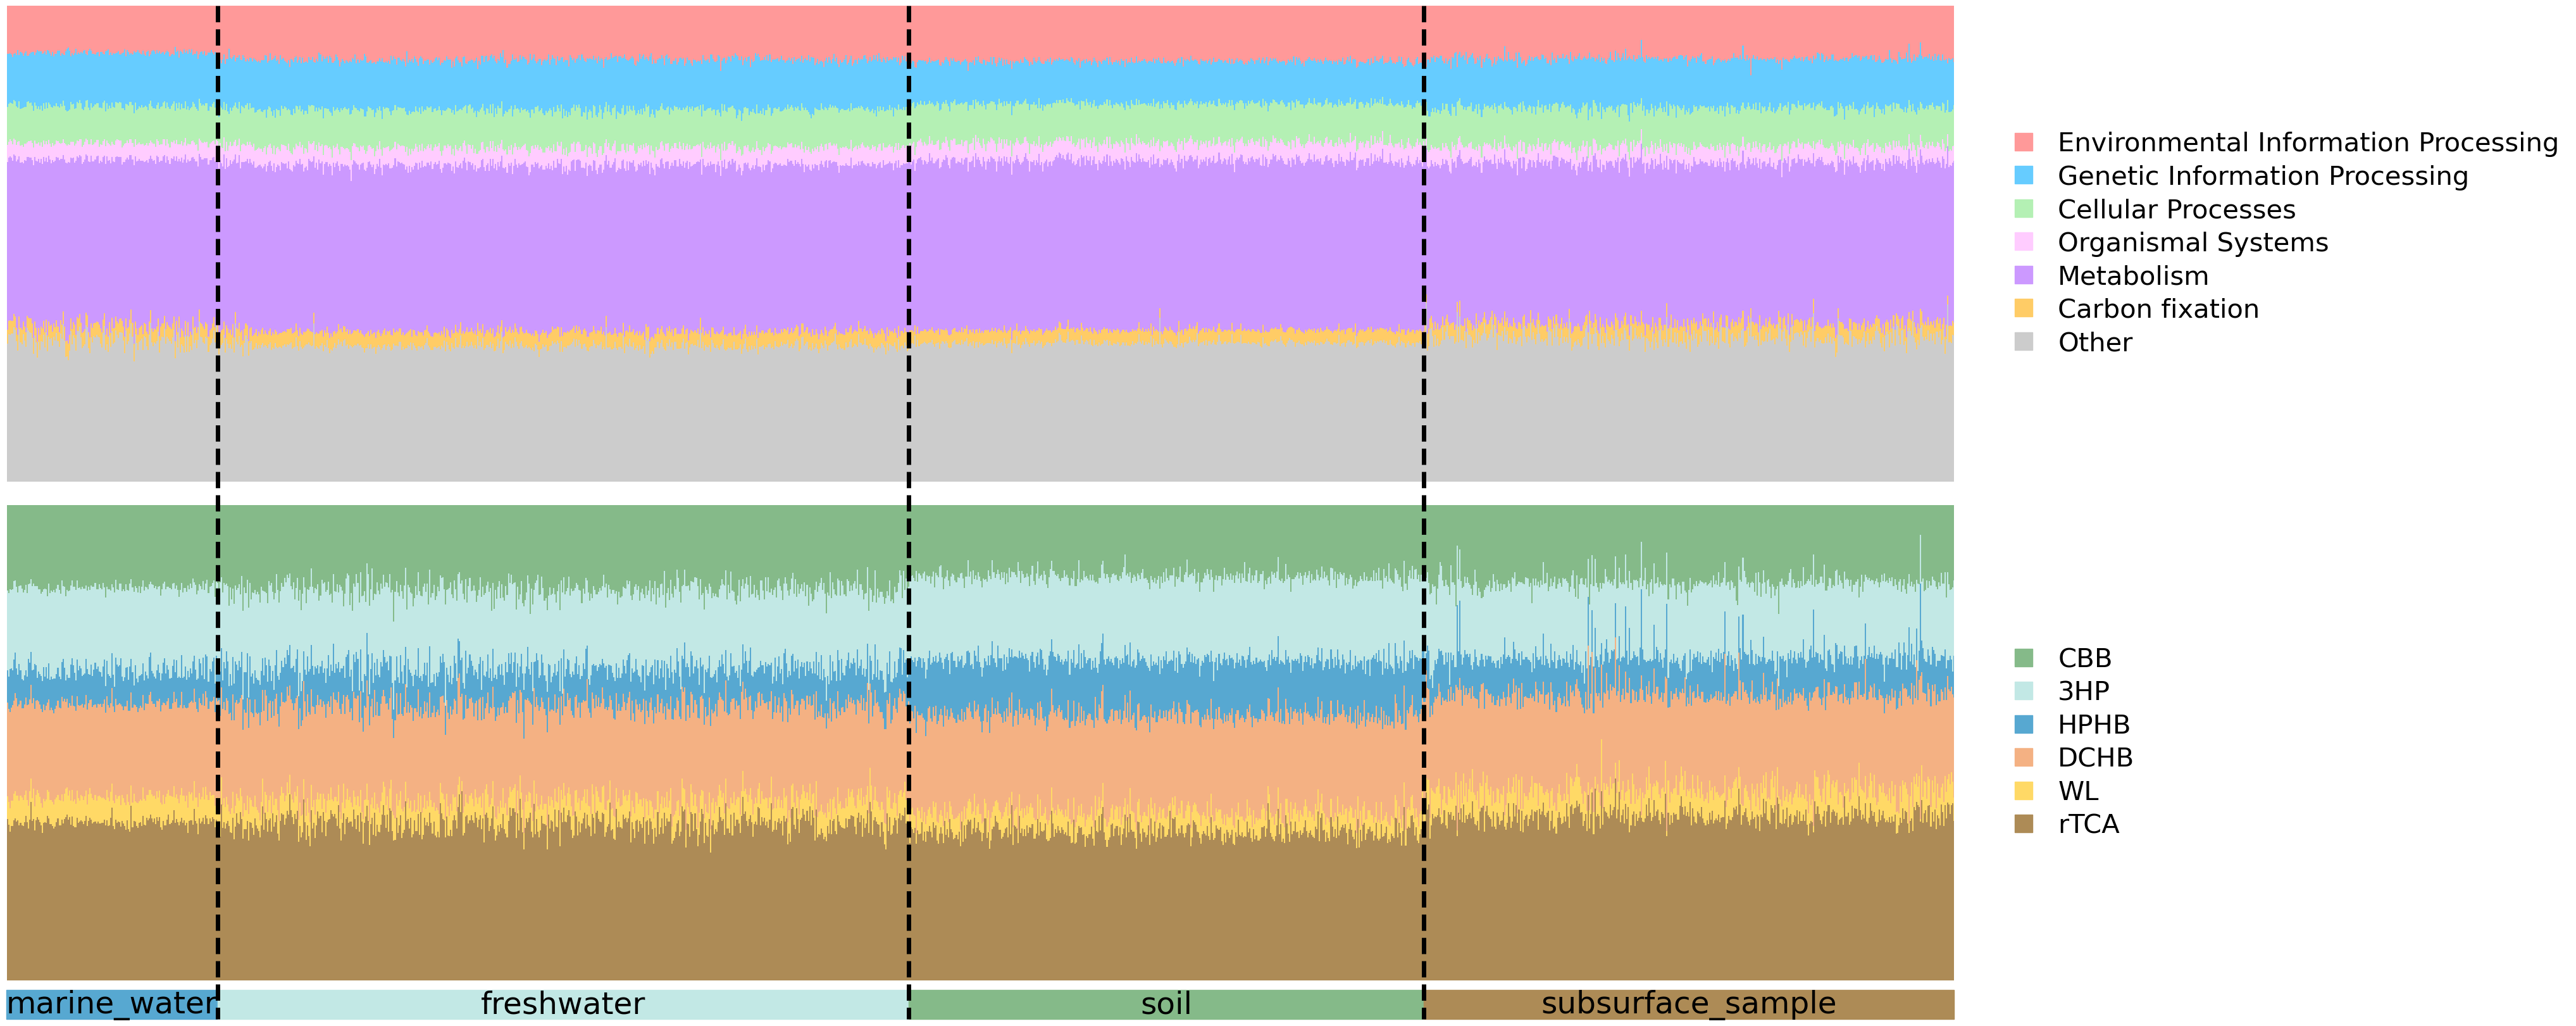

In [12]:

random_seed = 127 # random_seed to control within-group sample shuffle

tax["carbon_fixation_pathway"] = (
    tax["pathway"].astype(str)
    .str.replace(r"other|nan|cfp|wl\?|rglyc", "", regex=True)
    .str.replace("|", ";", regex=False)
)
tax["global_function_and_CFP"] = tax["global_function"].copy()
tax.loc[
    tax["carbon_fixation_pathway"].str.strip().replace("", pd.NA).notna(),
    "global_function_and_CFP"
] = "Carbon fixation"

top_categories = [
    "Other", "Carbon fixation", "Metabolism", "Organismal Systems",
    "Cellular Processes", "Genetic Information Processing",
    "Environmental Information Processing"
]
top_colors = {
    "Other": "#CCCCCC", "Carbon fixation": "#FFCC66", "Metabolism": "#CC99FF",
    "Organismal Systems": "#FFCCFF", "Cellular Processes": "#B4F0B4",
    "Genetic Information Processing": "#66CCFF",
    "Environmental Information Processing": "#FF9999"
}

bottom_map = {"rtca": "rTCA", "wl": "WL", "dchb": "DCHB", "hphb": "HPHB", "3hp": "3HP", "cbb": "CBB"}
bottom_colors = {
    "rTCA": "#ad8b56ff", "WL": "#ffd966ff", "DCHB": "#f4b183ff",
    "HPHB": "#57a8d1ff", "3HP": "#c2e8e5ff", "CBB": "#85ba89ff"
}

sample_groups = ['marine_water', 'freshwater', 'soil', 'subsurface_sample']
group_colors = {
    'marine_water': "#57a8d1ff", 'freshwater': "#c2e8e5ff",
    'soil': "#85ba89ff", 'subsurface_sample': "#ad8b56ff"
}

rng = np.random.default_rng(random_seed)
sample_order, boundaries = [], []
for grp in sample_groups:
    grp_samples = [s for s in sample_table.index[sample_table["sample_group"] == grp] if s in otu_rpo.columns]
    if random_seed is not None:
        rng.shuffle(grp_samples)
    sample_order.extend(grp_samples)
    boundaries.append(len(sample_order))

func_top = build_func_df("global_function_and_CFP", top_categories, otu_rpo, sample_order)
func_bottom = build_func_df("carbon_fixation_pathway", list(bottom_map.keys()), otu_rpo, sample_order)
func_bottom = func_bottom.rename(index=bottom_map)

rect_bottom, rect_h = -0.08, 0.06
compression_factor = 0.035

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(0.75 * compression_factor * len(sample_order), 20),
    gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.05}
)

handles_top, labels_top = plot_stacked(ax_top, func_top, top_colors)
handles_bottom, labels_bottom = plot_stacked(ax_bottom, func_bottom, bottom_colors)

ax_top.set_ylim(0, 1)
ax_bottom.set_ylim(0, 1)
for ax in [ax_top, ax_bottom]:
    ax.set_xlim(-0.5, len(sample_order) - 0.5)
    ax.axis("off")

ax_top.legend(handles_top[::-1], labels_top[::-1],
              loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=False, fontsize=30, handletextpad=0.3, labelspacing=0.3)
ax_bottom.legend(handles_bottom[::-1], labels_bottom[::-1],
                 loc="center left", bbox_to_anchor=(1.01, 0.5),
                 frameon=False, fontsize=30, handletextpad=0.3, labelspacing=0.3)

plt.tight_layout(pad=0.5)
add_dividers_and_rectangles(fig, ax_top, ax_bottom, boundaries, rect_bottom, rect_h)
#plt.savefig("../outputs/func_cat_distrib.svg", format="svg", bbox_inches='tight', dpi=300)
plt.show()

/var/folders/xd/tzd66fkj5s5676432q_qccqr0000gn/T/ipykernel_77764/3871858456.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.5)


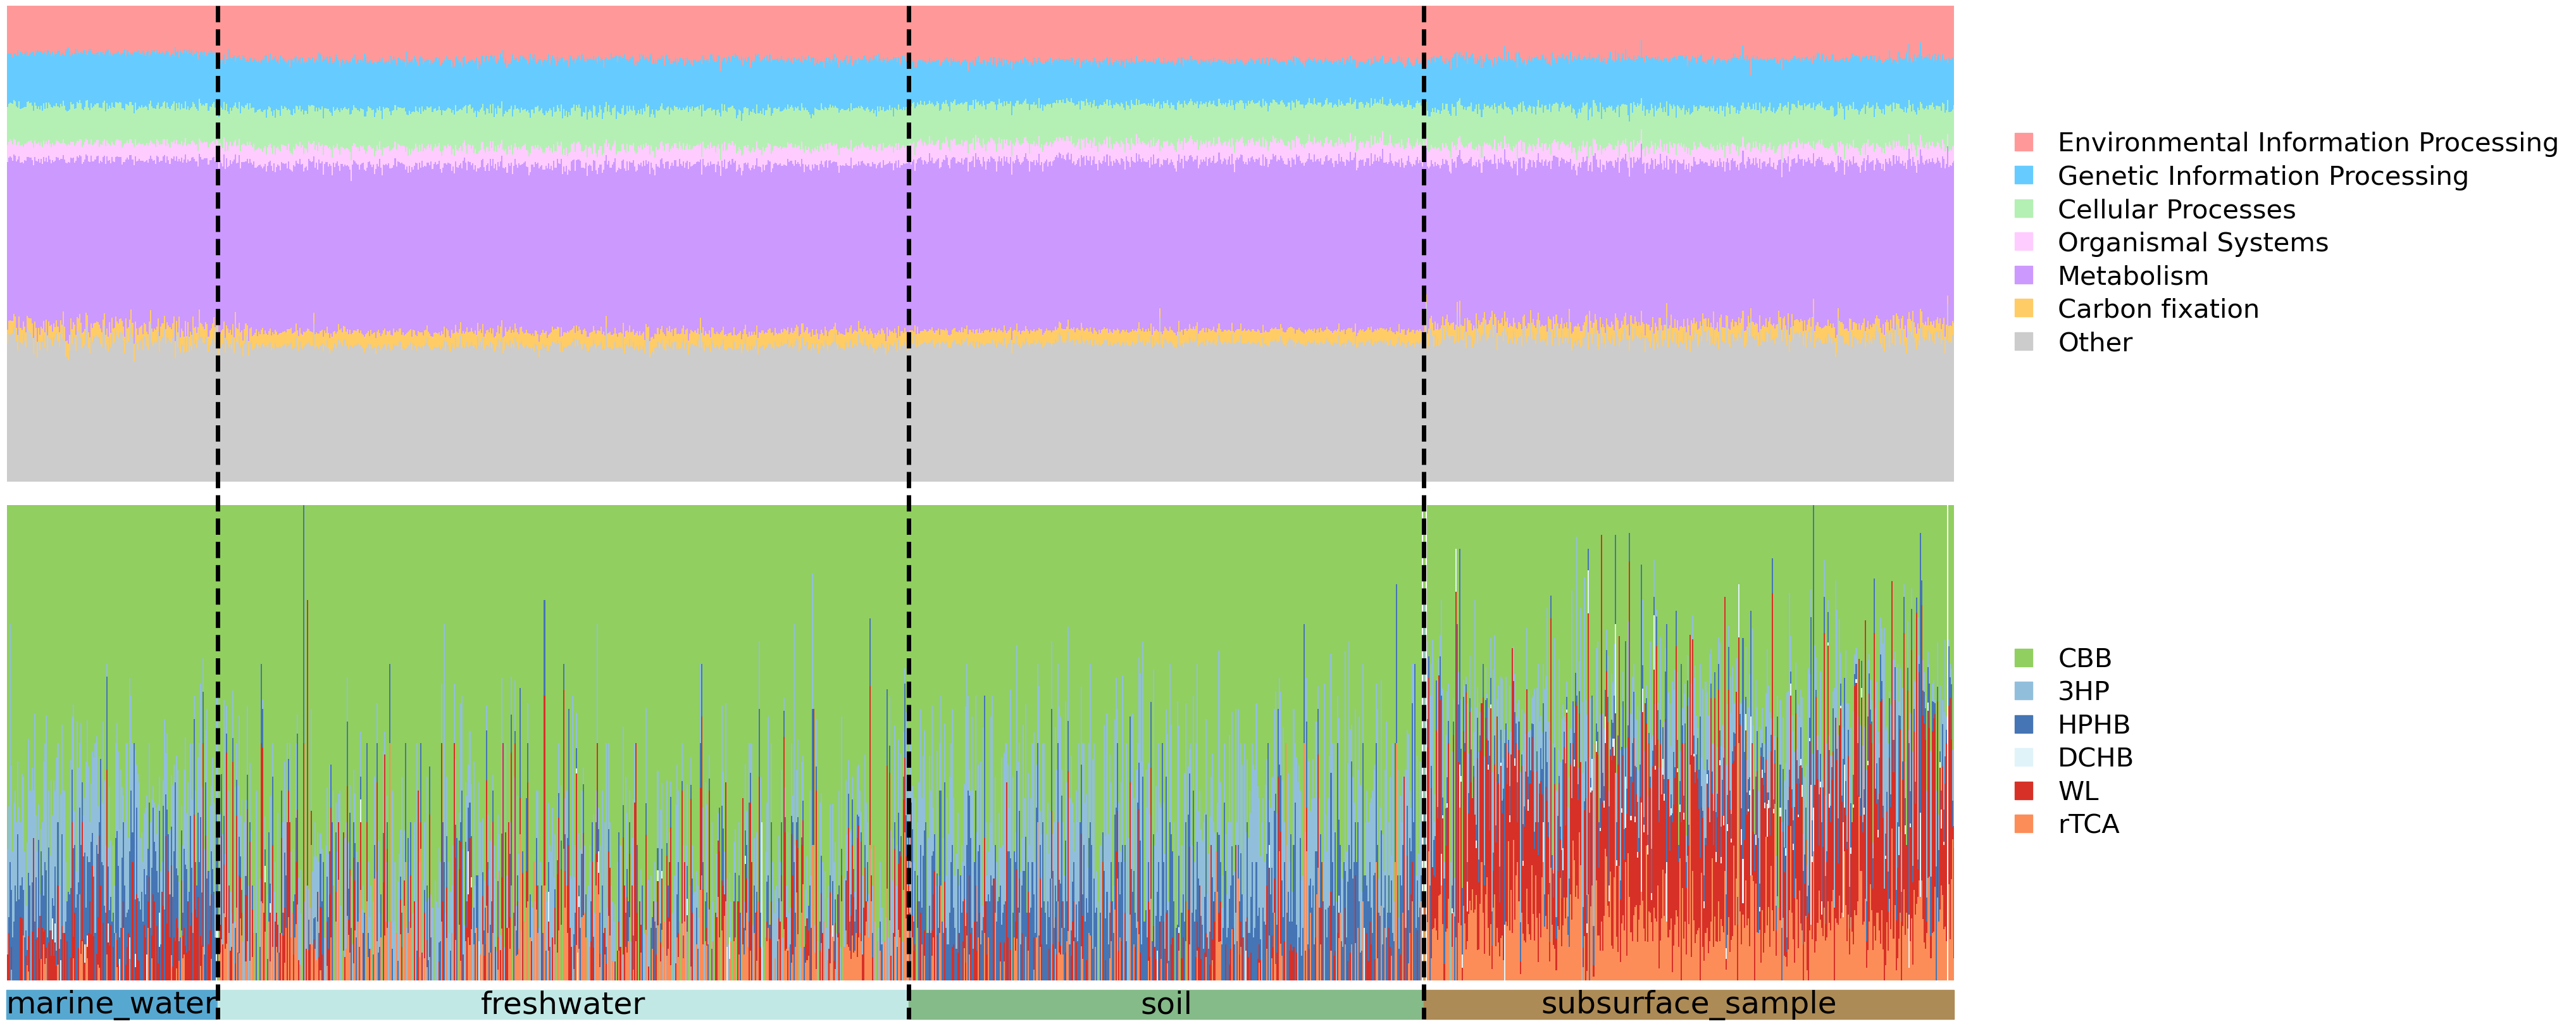

In [13]:
bottom_colors = {
    "rTCA": "#fc8d59", "WL": "#d73027", "DCHB": "#e0f3f8",
    "HPHB": "#4575b4", "3HP": "#91bfdb", "CBB": "#91cf60"
}

key_gene_map = {
    "rtca_1": "rTCA", "wl_1": "WL", "dchb_1": "DCHB",
    "hphb_1": "HPHB", "hp_1": "3HP", "cbb_1": "CBB"
}

func_bottom_key = build_func_df("key_genes", list(key_gene_map.keys()), otu_rpo, sample_order)
func_bottom_key = func_bottom_key.rename(index=key_gene_map)

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(0.75 * compression_factor * len(sample_order), 20),
    gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.05}
)

handles_top, labels_top = plot_stacked(ax_top, func_top, top_colors)
handles_bottom, labels_bottom = plot_stacked(ax_bottom, func_bottom_key, bottom_colors)

ax_top.set_ylim(0, 1)
ax_bottom.set_ylim(0, 1)
for ax in [ax_top, ax_bottom]:
    ax.set_xlim(-0.5, len(sample_order) - 0.5)
    ax.axis("off")

ax_top.legend(handles_top[::-1], labels_top[::-1],
              loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=False, fontsize=30, handletextpad=0.3, labelspacing=0.3)
ax_bottom.legend(handles_bottom[::-1], labels_bottom[::-1],
                 loc="center left", bbox_to_anchor=(1.01, 0.5),
                 frameon=False, fontsize=30, handletextpad=0.3, labelspacing=0.3)

plt.tight_layout(pad=0.5)
add_dividers_and_rectangles(fig, ax_top, ax_bottom, boundaries, rect_bottom, rect_h)
plt.savefig("../outputs/func_cat_distrib_key.png", bbox_inches='tight', dpi=300)
plt.savefig("../outputs/func_cat_distrib_key.svg", bbox_inches='tight', dpi=300, transparent=True)

plt.show()

/var/folders/xd/tzd66fkj5s5676432q_qccqr0000gn/T/ipykernel_77307/4218465663.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.5)


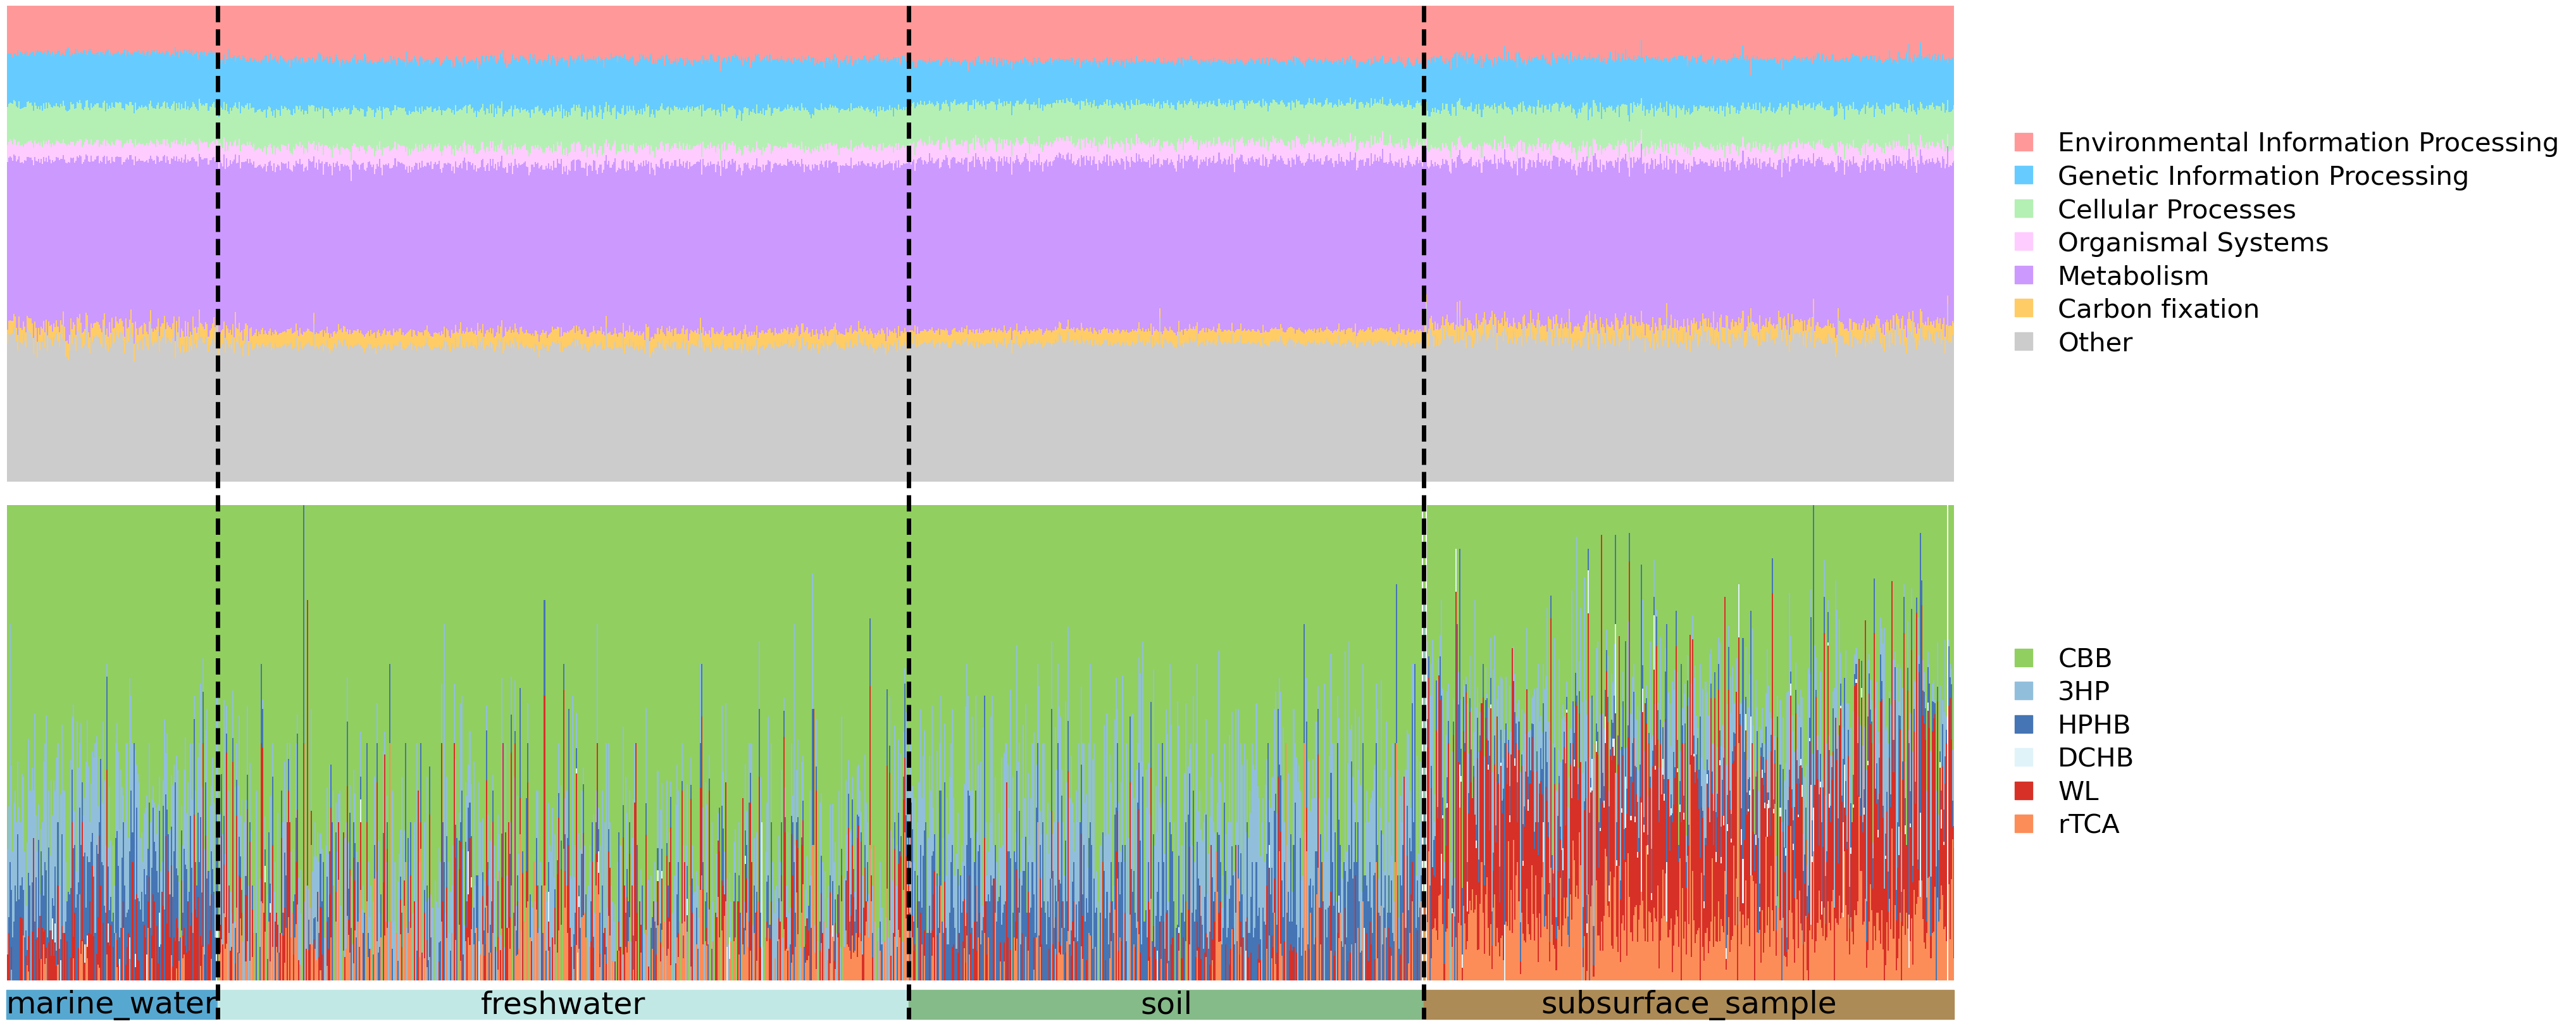

/var/folders/xd/tzd66fkj5s5676432q_qccqr0000gn/T/ipykernel_77764/1211690742.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.5)


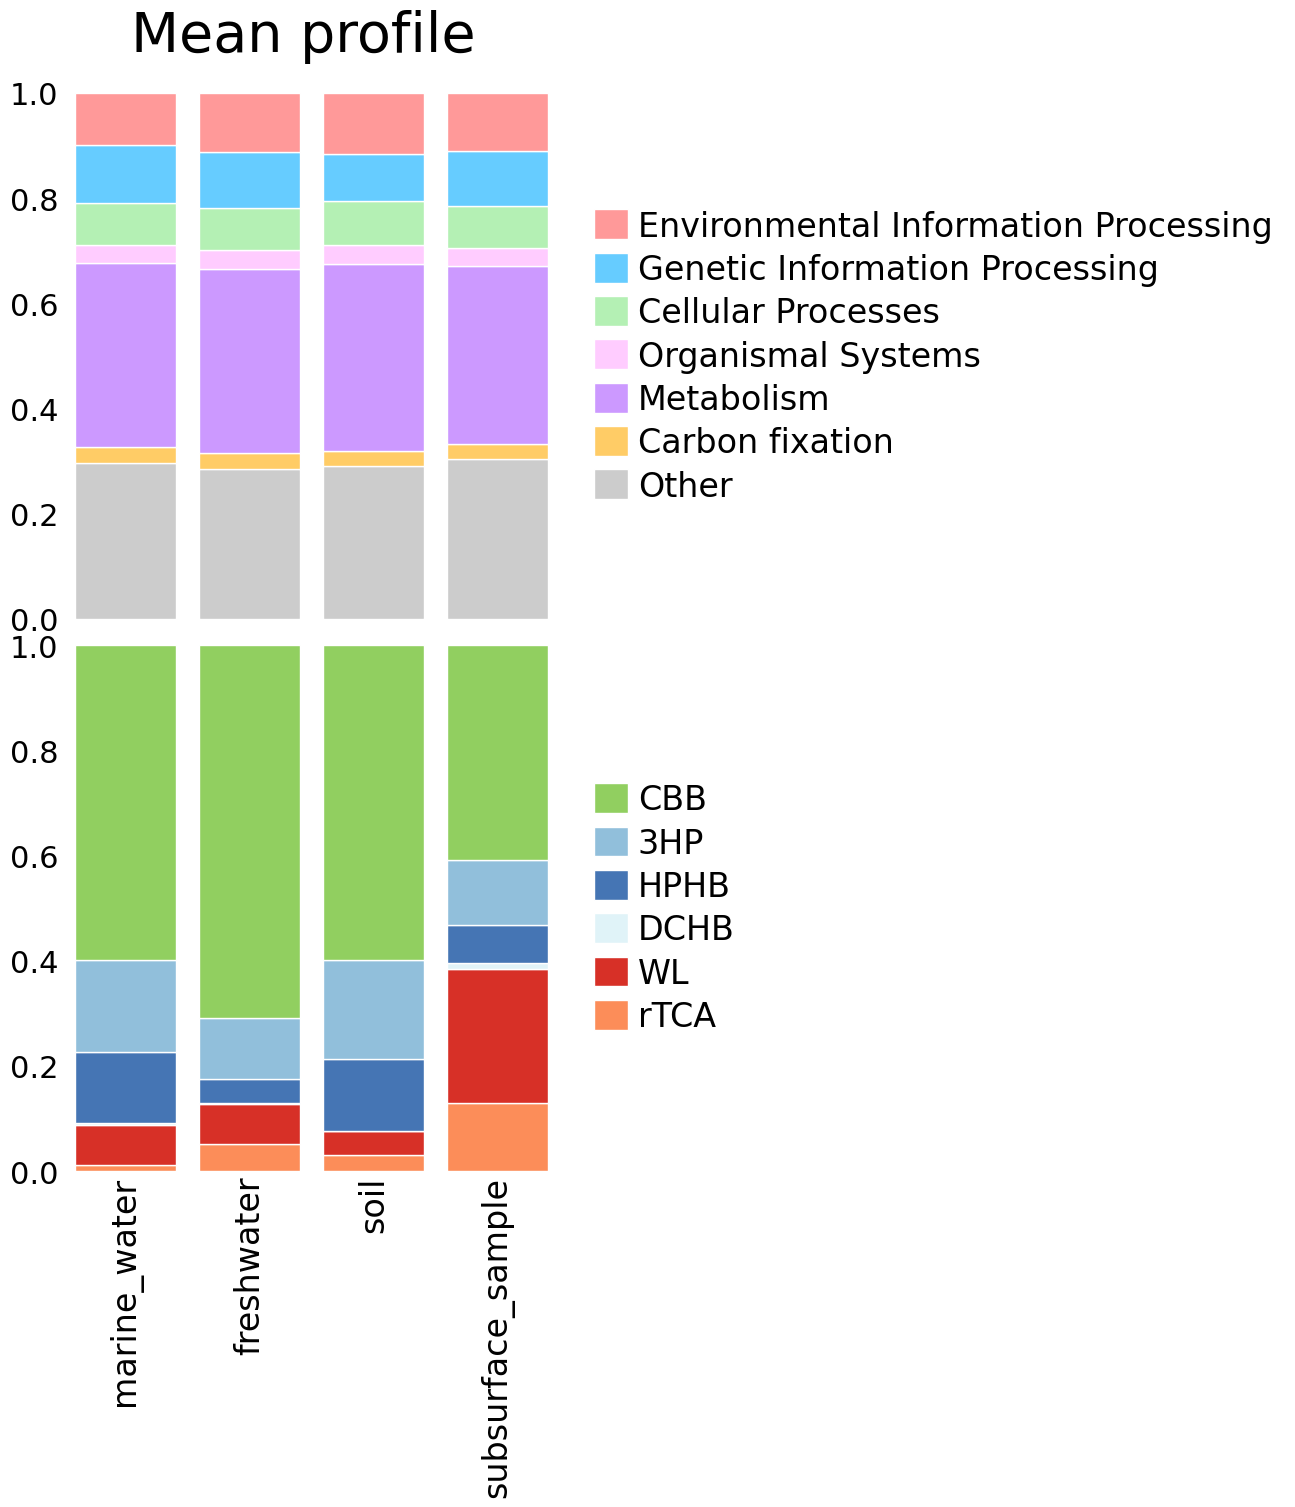

In [26]:
env_per_sample = sample_table.loc[sample_order, "sample_group"].copy()
env_order = env_per_sample.dropna().drop_duplicates().tolist()


def _group_mean(func_df, env_series):
    return func_df.T.groupby(env_series).mean().T[env_order]

def _plot_stacked_avg(ax, df, color_dict, width=0.82):
    x = np.arange(df.shape[1])
    bottom = np.zeros(df.shape[1])
    handles, labels = [], []
    for row_name in df.index:
        values = df.loc[row_name].values
        bars = ax.bar(x, values, bottom=bottom, width=width,
                      color=color_dict[row_name], edgecolor="white", linewidth=1)
        bottom += values
        handles.append(bars[0])
        labels.append(row_name)
    return handles, labels

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(1.6 * len(env_order), 14),
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.05}
)

handles_top,    labels_top    = _plot_stacked_avg(ax_top,    _group_mean(func_top,        env_per_sample), top_colors)
handles_bottom, labels_bottom = _plot_stacked_avg(ax_bottom, _group_mean(func_bottom_key, env_per_sample), bottom_colors)

ax_top.set_ylim(0, 1)
ax_bottom.set_ylim(0, 1)

for ax in [ax_top, ax_bottom]:
    ax.set_xlim(-0.5, len(env_order) - 0.5)
    ax.set_xticks(np.arange(len(env_order)))
    ax.set_xticklabels(env_order, rotation=90, fontsize=24)
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", length=0, labelsize=22)
    for spine in ax.spines.values():
        spine.set_visible(False)

ax_top.set_xticklabels([])

ax_top.legend(handles_top[::-1], labels_top[::-1],
              loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=False, fontsize=24, handletextpad=0.3, labelspacing=0.3,
              handlelength=1.0, handleheight=1.0)
ax_bottom.legend(handles_bottom[::-1], labels_bottom[::-1],
                 loc="center left", bbox_to_anchor=(1.01, 0.5),
                 frameon=False, fontsize=24, handletextpad=0.3, labelspacing=0.3,
                 handlelength=1.0, handleheight=1.0)

fig.suptitle("Mean profile", fontsize=40, y=0.94)

plt.tight_layout(pad=0.5)
plt.savefig("../outputs/func_cat_distrib_key_by_environment.svg",
            bbox_inches="tight", dpi=300, transparent=True)
plt.show()

In [14]:
chi2_all, p_all, *_ = chi2_contingency(build_raw_contingency(
    "global_function_and_CFP", top_categories, otu_rpo,
    sample_table.loc[func_top.columns, "sample_group"]
))
print("All functions")
print("chi2 =", chi2_all)
print("p =", p_all)

cont_cfix = build_raw_contingency(
    "key_genes",
    list(key_gene_map.keys()),
    otu_rpo,
    sample_table.loc[func_bottom_key.columns, "sample_group"]
)
cont_cfix.index = func_bottom_key.index
chi2_cfix, p_cfix, *_ = chi2_contingency(cont_cfix)
print("\nCarbon fixation pathways")
print("chi2 =", chi2_cfix)
print("p =", p_cfix)

All functions
chi2 = 836.2014780835879
p = 6.22662828674392e-166

Carbon fixation pathways
chi2 = 70.29604095966401
p = 3.956113635486399e-09


In [15]:
print("PERMANOVA — All functions")
print(permanova(
    beta_diversity("braycurtis", func_top.T.values, ids=func_top.columns),
    sample_table.loc[func_top.columns, "sample_group"],
    permutations=9999
))

print("\nPERMANOVA — Carbon fixation pathways")
print(permanova(
    beta_diversity("braycurtis", func_bottom_key.T.values, ids=func_bottom_key.columns),
    sample_table.loc[func_bottom_key.columns, "sample_group"],
    permutations=9999
))

PERMANOVA — All functions
method name                PERMANOVA
test statistic name         pseudo-F
sample size                     1513
number of groups                   4
test statistic            240.152532
p-value                       0.0001
number of permutations          9999
Name: PERMANOVA results, dtype: object

PERMANOVA — Carbon fixation pathways
method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1513
number of groups                  4
test statistic                  NaN
p-value                      0.0001
number of permutations         9999
Name: PERMANOVA results, dtype: object


# Hierarchical KEGG function enrichment heatmaps

In [16]:
orders = {
    "global_function": [
        "Metabolism", "Genetic Information Processing",
        "Environmental Information Processing", "Organismal Systems",
        "Cellular Processes", "Other",
    ],
    "metabolism_sub_function": [
        "Energy metabolism", "Amino acid metabolism", "Nucleotide metabolism",
        "Metabolism of other amino acids", "Carbohydrate metabolism",
        "Metabolism of cofactors and vitamins", "Lipid metabolism", "Other",
    ],
    "energy_metabolism_sub_function": [
        "Carbon fixation", "Nitrogen metabolism", "Oxidative phosphorylation",
        "Sulfur metabolism", "Methane metabolism", "Photosynthesis",
        "Photosynthesis - antenna proteins", "Other",
    ],
}

heatmaps = {}
for col in orders:
    h = (
        otu_rpo.join(tax[[col]])
        .assign(**{col: lambda df: df[col].str.split(';')})
        .explode(col)
    )
    if col == "metabolism_sub_function":
        h[col] = h[col].replace(
            ["Biosynthesis of other secondary metabolites",
             "Glycan biosynthesis and metabolism",
             "Xenobiotics biodegradation and metabolism",
             "Metabolism of terpenoids and polyketides"], "Other"
        )
    h = (
        h.reset_index()
        .melt(id_vars=[otu_rpo.index.name, col], var_name="sample", value_name="abundance")
        .merge(sample_table[["sample_group"]], left_on="sample", right_index=True)
        .drop_duplicates(subset=[otu_rpo.index.name, col, "sample"])
    )
    heatmap = h.groupby([col, "sample_group"])["abundance"].mean().unstack().reindex(orders[col])
    heatmaps[col] = heatmap.sub(heatmap.mean(axis=1), axis=0).div(heatmap.std(axis=1), axis=0).fillna(0)

In [17]:
def _plot_heatmap(data, figsize, filename):
    fig, ax = plt.subplots(figsize=figsize)
    cbar_ax = fig.add_axes([0.125, 0.92, 0.775, 0.04])
    hm = sns.heatmap(data, cmap="viridis", ax=ax, cbar_ax=cbar_ax,
                     cbar_kws={"orientation": "horizontal", "label": "Z-score"})
    cbar = hm.collections[0].colorbar
    cbar.ax.xaxis.set_ticks_position("top")
    cbar.ax.xaxis.set_label_position("top")
    cbar.ax.tick_params(labeltop=True, labelbottom=False, labelsize=12)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.tick_params(labelsize=12)
    plt.savefig(f"../outputs/{filename}", format="svg", bbox_inches="tight", transparent=True)
    plt.show()

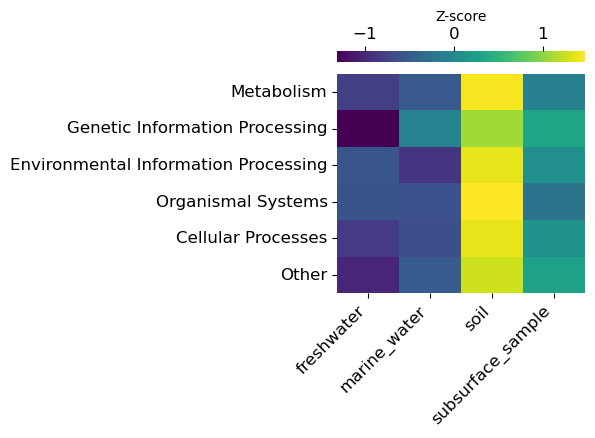

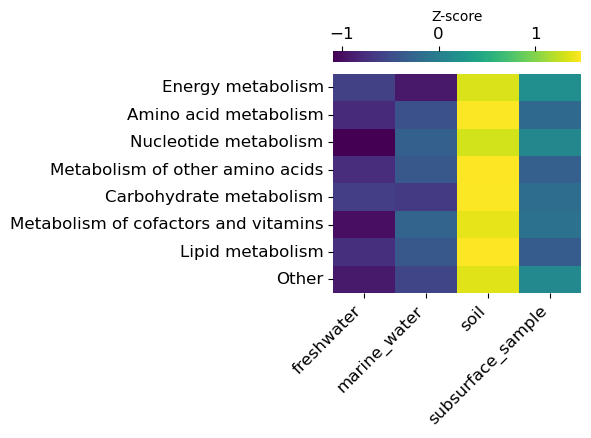

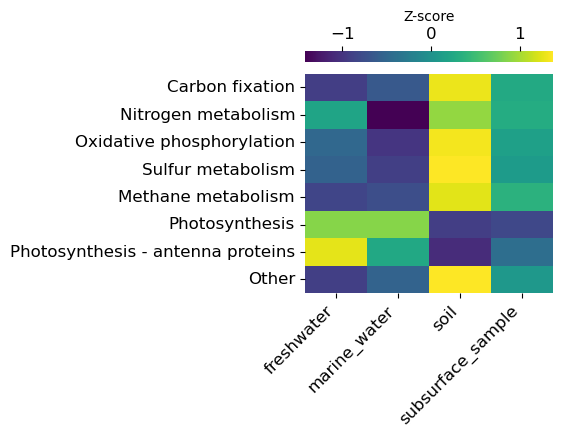

In [18]:
for col, filename in [
    ("global_function",                "heatmap_z_score_global_function.svg"),
    ("metabolism_sub_function",        "heatmap_z_score_metabolism_sub_function.svg"),
    ("energy_metabolism_sub_function", "heatmap_z_score_energy_metabolism_sub_function.svg"),
]:
    _plot_heatmap(heatmaps[col], (3.2, 2.85), filename)

In [19]:
# from here, we want to focus on marker genes only

# I make a new col whihc will make it easier for plotting 
keys_pattern = r"(cbb_1|rtca_1|wl_1|hp_1|hphb_1|dchb_1)"
tax["key_genes_clean"] = tax["key_genes"].str.extract(keys_pattern, expand=False).replace(
    {"cbb_1": "CBB", "rtca_1": "rTCA", "wl_1": "WL", "hp_1": "3HP", "hphb_1": "HPHB", "dchb_1": "DCHB"}
)



In [20]:
keys_pattern = r"(cbb_1|rtca_1|wl_1|hp_1|hphb_1|dchb_1)"
tax["key_genes_clean"] = tax["key_genes"].str.extract(keys_pattern, expand=False).replace(
    {"cbb_1": "CBB", "rtca_1": "rTCA", "wl_1": "WL", "hp_1": "3HP", "hphb_1": "HPHB", "dchb_1": "DCHB"}
)

ko_abund = (
    otu_rpo.join(tax[["key_genes_clean"]])
    .reset_index()
    .melt(id_vars=[otu_rpo.index.name, "key_genes_clean"], var_name="sample", value_name="abundance")
    .merge(sample_table[["sample_group"]], left_on="sample", right_index=True)
    .drop_duplicates(subset=[otu_rpo.index.name, "key_genes_clean", "sample"])
)

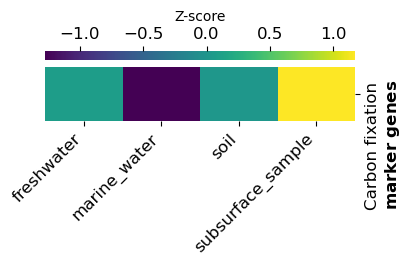

In [21]:
marker_row = ko_abund.groupby(["key_genes_clean", "sample_group"])["abundance"].mean().unstack().mean(axis=0).to_frame().T
marker_row.index = ["Carbon fixation\n$\\mathbf{marker\\ genes}$"]
marker_row = marker_row.sub(marker_row.mean(axis=1), axis=0).div(marker_row.std(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(4, 0.7))
cbar_ax = fig.add_axes([0.125, 0.99, 0.775, 0.12])
hm = sns.heatmap(marker_row, cmap="viridis", ax=ax, cbar_ax=cbar_ax,
                 cbar_kws={"orientation": "horizontal", "label": "Z-score"})
cbar = hm.collections[0].colorbar
cbar.ax.xaxis.set_ticks_position("top")
cbar.ax.xaxis.set_label_position("top")
cbar.ax.tick_params(labeltop=True, labelbottom=False, labelsize=12)
ax.yaxis.tick_right()
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.tick_params(labelsize=12)
plt.savefig("../outputs/heatmap_z_score_marker_genes_all.svg", format="svg", bbox_inches="tight", transparent=True)
plt.show()

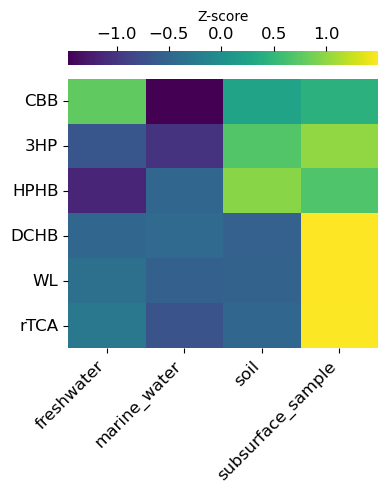

In [22]:
heatmap = ko_abund.groupby(["key_genes_clean", "sample_group"])["abundance"].mean().unstack()
heatmap = heatmap.reindex(["CBB", "3HP", "HPHB", "DCHB", "WL", "rTCA"])
heatmap = heatmap.sub(heatmap.mean(axis=1), axis=0).div(heatmap.std(axis=1), axis=0).fillna(0)
_plot_heatmap(heatmap, (4, 3.5), "heatmap_z_score_marker_genes_detailed.svg")